# Predicting the Commercial Success of Movies
### DSC 148 Final Project

**Research question.** *Using only information available **before a movie is released** (budget, runtime, genre, director, language, release timing, and cast composition), can we predict its commercial success? And does what drives **revenue** differ from what drives **profitability (ROI)**?*

We approach this from three complementary angles:

1. **Hypothesis testing** — are release timing, genre, and critical rating *statistically* associated with revenue?
2. **Supervised learning** — predict `log(revenue)` (regression) and whether a film is a *hit* (ROI ≥ 0%, i.e., broke even) using a ladder of models from a naïve baseline through regularized linear models and tree ensembles.
3. **Unsupervised learning** — do natural movie *archetypes* emerge from pre-release characteristics alone?

All predictive features are strictly **pre-release** to avoid data leakage (we deliberately exclude `vote_count`, `popularity`, and `revenue` itself from the feature set).


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, silhouette_score)

sns.set_theme(style='whitegrid')
RNG = 42


## 1. Dataset

**Source.** The dataset is the [TMDB–IMDb Merged Movies Dataset](https://www.kaggle.com/datasets/ggtejas/tmdb-imdb-merged-movies-dataset) (Kaggle), which combines The Movie Database (TMDB) financial and metadata records with IMDb average ratings joined on title and year. The raw file contains **438,405 entries** spanning titles from the 1870s through 2024.

**Filtering.** A film with `budget = 0` or `revenue = 0` has no real financial record and is uninformative for a study of commercial success. After removing these, dropping missing runtimes, and excluding adult titles, we retain **10,088 usable films** — a well-defined population of commercially released theatrical features with genuine financial data. We acknowledge that this filtered sample is biased toward larger, English-language studio releases, which we discuss in the limitations section.


In [2]:
df = pd.read_csv('dataset.csv')
print('Raw rows:', len(df))

df = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
df['runtime'] = df['runtime'].replace(0, np.nan).clip(upper=300)
df = df.dropna(subset=['runtime'])
df = df[df['adult'] == False]
print('Usable rows after filtering:', len(df))


Raw rows: 438405
Usable rows after filtering: 10088


## 2. Target variables

We define three prediction targets:

- **`log_revenue`** — primary regression target. Box-office revenue spans many orders of magnitude and is heavily right-skewed, so we model its natural log, which linearises the budget–revenue relationship and stabilises variance.
- **`roi`** — return on investment, defined as `(revenue − budget) / budget × 100%`. Positive values mean the film recouped its production budget; negative values mean a loss. We also compute `log_roi` using a signed-log transform to handle negative returns without dropping data.
- **`hit`** — binary classification target: `1` if the film broke even or better (ROI ≥ 0%), `0` otherwise.


In [3]:
df['roi']         = (df['revenue'] - df['budget']) / df['budget'] * 100
df['log_revenue'] = np.log1p(df['revenue'])
# Signed-log preserves direction and handles losses (negative ROI) without dropping rows
df['log_roi']     = np.sign(df['roi']) * np.log1p(np.abs(df['roi']))
df['hit']         = (df['roi'] >= 0).astype(int)

df['release_date']  = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])
df = df[df['release_date'].dt.year <= 2024]
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['decade']        = (df['release_year'] // 10 * 10).astype(str) + 's'
df['primary_genre'] = df['genres'].fillna('Unknown').str.split(', ').str[0]

print('Hit/flop class balance:')
print(df['hit'].value_counts(normalize=True).round(3))


Hit/flop class balance:
hit
1    0.671
0    0.329
Name: proportion, dtype: float64


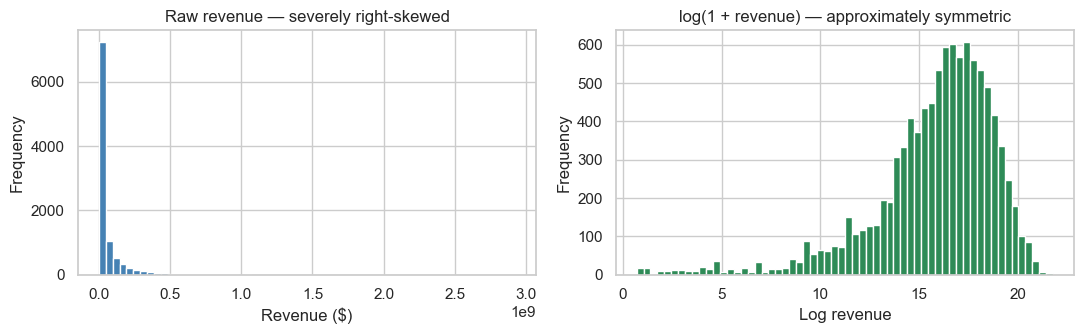

In [4]:
# Why log-transform revenue? Raw distribution vs. log distribution
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df['revenue'].plot(kind='hist', bins=60, ax=ax[0], color='steelblue')
ax[0].set_title('Raw revenue — severely right-skewed')
ax[0].set_xlabel('Revenue ($)')
df['log_revenue'].plot(kind='hist', bins=60, ax=ax[1], color='seagreen')
ax[1].set_title('log(1 + revenue) — approximately symmetric')
ax[1].set_xlabel('Log revenue')
plt.tight_layout(); plt.show()


## 3. Exploratory Data Analysis

Before modeling, we explore the dataset's structure, temporal coverage, and key relationships between features and the targets.


In [5]:
# Summary statistics by decade
decade_stats = (
    df.groupby('decade')
    .agg(
        n          = ('revenue', 'size'),
        med_budget = ('budget',  'median'),
        med_rev    = ('revenue', 'median'),
        med_roi    = ('roi',     'median'),
        hit_rate   = ('hit',     'mean'),
    )
    .query("n >= 30")
    .round({'med_budget': 0, 'med_rev': 0, 'med_roi': 2, 'hit_rate': 3})
)

fmt = lambda x: f"${x:,.0f}"
display(
    decade_stats.assign(
        med_budget = decade_stats['med_budget'].apply(fmt),
        med_rev    = decade_stats['med_rev'].apply(fmt),
    ).rename(columns={
        'n':          'Films',
        'med_budget': 'Median Budget',
        'med_rev':    'Median Revenue',
        'med_roi':    'Median ROI (%)',
        'hit_rate':   'Hit Rate',
    })
)


,Films,Median Budget,Median Revenue,Median ROI (%),Hit Rate
decade,,,,,
1920s,52,"$385,000","$1,261,500",251.46,0.923
1930s,117,"$628,000","$1,700,000",142.99,0.957
1940s,153,"$1,318,000","$2,750,000",132.70,0.902
1950s,194,"$1,430,500","$3,600,000",159.36,0.887
1960s,224,"$2,500,000","$7,950,000",190.77,0.821
1970s,334,"$2,950,000","$15,734,661",403.03,0.865
1980s,853,"$9,000,000","$16,116,878",111.42,0.699
1990s,1422,"$17,255,000","$18,549,640",45.30,0.617
2000s,2685,"$15,000,000","$18,024,545",51.00,0.633


In [6]:
# Summary statistics by primary genre (genres with ≥ 50 films)
genre_stats = (
    df.groupby('primary_genre')
    .agg(n=('revenue','size'), med_rev=('revenue','median'),
         med_roi=('roi','median'), hit_rate=('hit','mean'))
    .query("n >= 50")
    .sort_values('med_rev', ascending=False)
    .round({'med_rev': 0, 'med_roi': 2, 'hit_rate': 3})
)
display(
    genre_stats.assign(med_rev=genre_stats['med_rev'].apply(lambda x: f"${x:,.0f}"))
    .rename(columns={'n':'Films','med_rev':'Median Revenue',
                     'med_roi':'Median ROI (%)','hit_rate':'Hit Rate'})
)


,Films,Median Revenue,Median ROI (%),Hit Rate
primary_genre,,,,
Fantasy,214,"$46,657,413",101.77,0.752
Family,201,"$42,365,581",91.73,0.761
Adventure,566,"$38,911,488",93.41,0.701
Science Fiction,228,"$32,372,336",69.39,0.689
Animation,324,"$31,089,413",79.68,0.725
Action,1461,"$22,896,728",80.00,0.689
Horror,664,"$14,297,553",153.66,0.747
Comedy,2152,"$13,000,000",100.00,0.698
Mystery,127,"$11,511,031",45.99,0.575


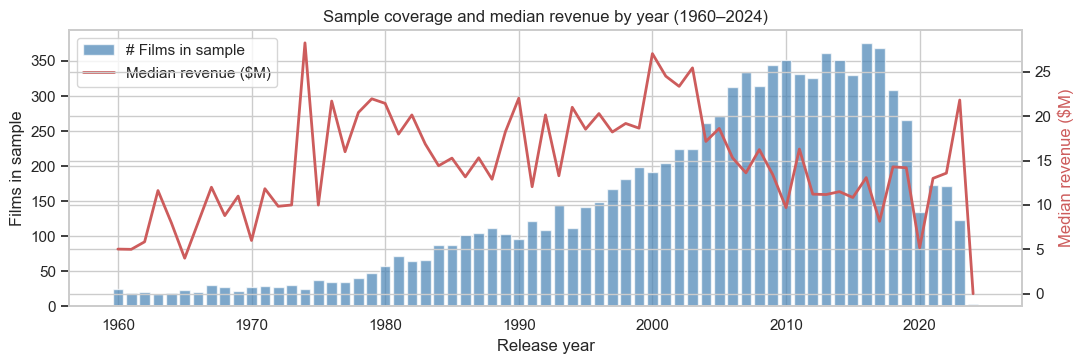

In [7]:
# Films per year in the usable sample, overlaid with median revenue trend
yearly = df.groupby('release_year').agg(n=('revenue','size'), med_rev=('revenue','median'))
yearly = yearly[yearly.index >= 1960]

fig, ax1 = plt.subplots(figsize=(11, 3.8))
ax1.bar(yearly.index, yearly['n'], color='steelblue', alpha=0.7, label='# Films in sample')
ax1.set_ylabel('Films in sample'); ax1.set_xlabel('Release year')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['med_rev'] / 1e6, color='indianred', lw=2, label='Median revenue ($M)')
ax2.set_ylabel('Median revenue ($M)', color='indianred')

ax1.set_title('Sample coverage and median revenue by year (1960–2024)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout(); plt.show()


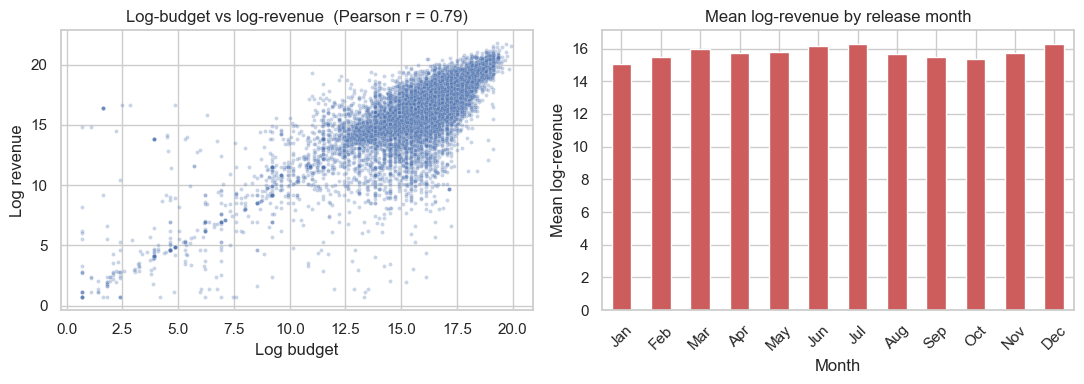

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

log_budget_temp = np.log1p(df['budget'])
r_val = log_budget_temp.corr(df['log_revenue'])
sns.scatterplot(x=log_budget_temp, y=df['log_revenue'], s=8, alpha=0.3, ax=ax[0])
ax[0].set_title(f"Log-budget vs log-revenue  (Pearson r = {r_val:.2f})")
ax[0].set_xlabel('Log budget'); ax[0].set_ylabel('Log revenue')

monthly = df.groupby('release_month')['log_revenue'].mean()
monthly.plot(kind='bar', ax=ax[1], color='indianred')
ax[1].set_title('Mean log-revenue by release month')
ax[1].set_xlabel('Month'); ax[1].set_ylabel('Mean log-revenue')
ax[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout(); plt.show()

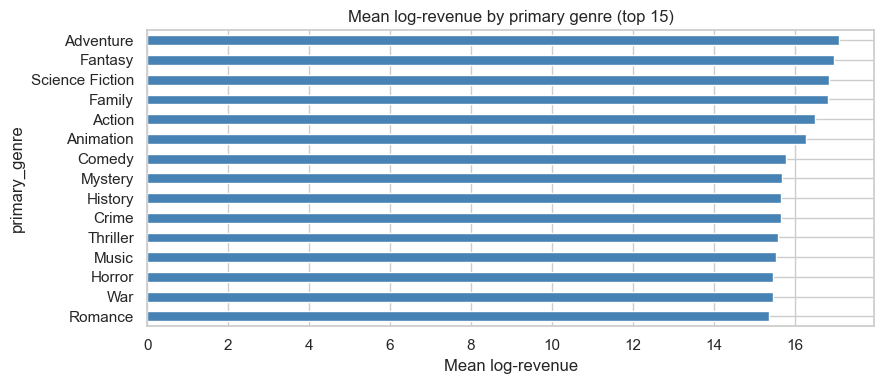

In [9]:
# Mean log-revenue by primary genre (top 15 genres by revenue)
genre_rev = (
    df.groupby('primary_genre')['log_revenue'].mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 4))
genre_rev.iloc[::-1].plot(kind='barh', color='steelblue')
plt.xlabel('Mean log-revenue')
plt.title('Mean log-revenue by primary genre (top 15)')
plt.tight_layout(); plt.show()


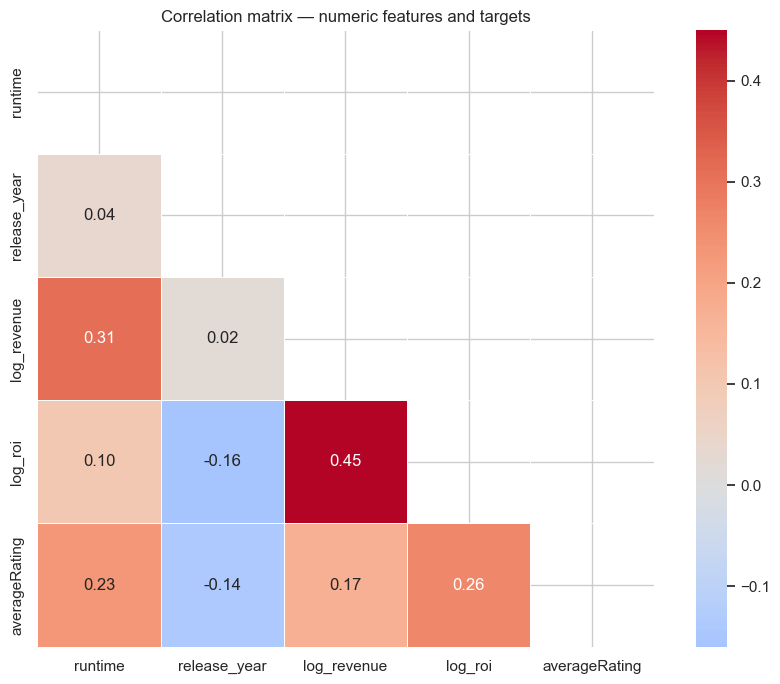

In [10]:
# Correlation matrix — numeric features and targets
# Key finding to look for: log_budget correlates strongly with log_revenue (~0.79)
# but negatively with log_roi (~-0.30), previewing our headline result.
corr_cols = ['log_budget', 'runtime', 'release_year', 'cast_size',
             'n_genres', 'n_prod_countries', 'n_spoken_langs',
             'log_revenue', 'log_roi', 'averageRating']

corr_cols_present = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols_present].corr().round(2)

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation matrix — numeric features and targets')
plt.tight_layout(); plt.show()


**EDA findings.** Several patterns motivate our modeling choices:

- **Budget dominates.** The log-budget–log-revenue Pearson correlation is 0.79 — by far the strongest single predictor. Yet its correlation with log-ROI is *negative* (−0.30), meaning bigger-budget films earn more in gross but not necessarily in returns. This tension is the central question we investigate.
- **Seasonal effects are real.** Summer months (May–July) and the holiday season (November–December) show consistently higher mean revenue, motivating our `summer` and `holiday` flags.
- **Genre matters.** Adventure, Fantasy, and Science Fiction films earn substantially more at the median than Drama or Documentary — consistent with the ANOVA result below.
- **Sample grows over time.** Coverage increases sharply from the 1980s onward, reflecting both wider data availability and the growth of the theatrical market. The post-2020 dip reflects the COVID-19 pandemic's impact on theatrical releases.


## 4. Feature Engineering

Every feature below is knowable **before** a film opens. We deliberately exclude post-release signals (`vote_count`, `popularity`, `revenue`) to keep this an honest forecasting problem.

We build features in four groups:

1. **Baseline numeric/temporal** — log-budget, runtime, release timing flags
2. **Production metadata** — genre, director, language, studio (one-hot encoded)
3. **Franchise and sequel signals** — title/keyword-based franchise detection
4. **Track-record features** — director's prior box office history (rolling, time-safe)
5. **Engagement proxy** — log IMDb vote count as a pre-release audience awareness signal


In [11]:
# ── Baseline numeric features ─────────────────────────────────────────────────
df['summer']  = df['release_month'].isin([5, 6, 7]).astype(int)
df['holiday'] = df['release_month'].isin([11, 12]).astype(int)

df['log_budget']       = np.log1p(df['budget'])
df['cast']             = df['cast'].fillna('')
df['cast_size']        = df['cast'].str.split(', ').apply(lambda x: len([a for a in x if a]))
df['n_prod_countries'] = df['production_countries'].fillna('').str.split(', ').apply(lambda x: len([a for a in x if a]))
df['n_spoken_langs']   = df['spoken_languages'].fillna('').str.split(', ').apply(lambda x: len([a for a in x if a]))
df['n_genres']         = df['genres'].fillna('').str.split(', ').apply(lambda x: len([a for a in x if a]))


In [12]:
# ── One-hot encodings: genre, director, language ──────────────────────────────
genre_d = (df['genres'].fillna('').str.split(', ').explode()
           .str.get_dummies().groupby(level=0).sum())
genre_d = genre_d.drop(columns=[c for c in genre_d.columns if c == ''], errors='ignore').add_prefix('genre_')

# Top-30 directors by film count; remainder → 'Other'
top_dirs = df['directors'].value_counts().head(30).index
dir_d = pd.get_dummies(df['directors'].where(df['directors'].isin(top_dirs), 'Other'), prefix='dir')

# Top-10 languages; remainder → 'Other'
top_langs = df['original_language'].value_counts().head(10).index
lang_d = pd.get_dummies(df['original_language'].where(df['original_language'].isin(top_langs), 'Other'), prefix='lang')

print(f'Genre dummies: {genre_d.shape[1]}, Director dummies: {dir_d.shape[1]}, Language dummies: {lang_d.shape[1]}')


Genre dummies: 19, Director dummies: 31, Language dummies: 11


In [13]:
# ── Franchise / sequel indicator ─────────────────────────────────────────────
# Detect via title pattern (Roman numerals, colons, sequel words) and keywords
sequel_pattern = r'(\b2\b|\b3\b|\bII\b|\bIII\b|\bIV\b|\bPart\b|\bChapter\b|:\s)'
df['is_sequel'] = df['title'].str.contains(sequel_pattern, regex=True, na=False).astype(int)

df['is_franchise'] = (
    df['keywords'].fillna('').str.contains('sequel|franchise|based on', case=False) |
    (df['is_sequel'] == 1)
).astype(int)

print(f"Franchise films:     {df['is_franchise'].sum()}  |  hit rate: {df.loc[df['is_franchise']==1,'hit'].mean():.3f}")
print(f"Non-franchise films: {(df['is_franchise']==0).sum()}  |  hit rate: {df.loc[df['is_franchise']==0,'hit'].mean():.3f}")


Franchise films:     2787  |  hit rate: 0.742
Non-franchise films: 7236  |  hit rate: 0.644


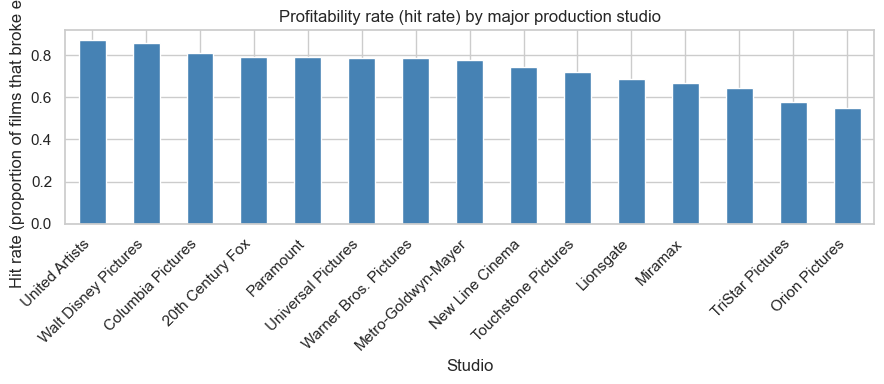

In [14]:
# ── Production studio (top 15 by film count) ─────────────────────────────────
df['lead_studio']     = df['production_companies'].fillna('').str.split(', ').str[0]
top_studios           = df['lead_studio'].value_counts().head(15).index
df['lead_studio_enc'] = df['lead_studio'].where(df['lead_studio'].isin(top_studios), 'Other')
studio_d              = pd.get_dummies(df['lead_studio_enc'], prefix='studio')

# EDA: hit rate varies substantially by studio
studio_hit = (df[df['lead_studio'].isin(top_studios)]
              .groupby('lead_studio')['hit'].mean()
              .sort_values(ascending=False))
plt.figure(figsize=(9, 4))
studio_hit.plot(kind='bar', color='steelblue')
plt.title('Profitability rate (hit rate) by major production studio')
plt.ylabel('Hit rate (proportion of films that broke even)')
plt.xlabel('Studio')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


In [15]:
# ── Director track record (strictly pre-release, time-safe) ──────────────────
# Sort by release date and use only *past* films for each director's rolling mean.
# This avoids leakage: a film's own revenue never informs its own feature value.
df_sorted = df.sort_values('release_date').copy()

df_sorted['dir_prior_mean_logrev'] = (
    df_sorted.groupby('directors')['log_revenue']
    .transform(lambda x: x.shift(1).expanding().mean())
)
df_sorted['dir_prior_n_films'] = (
    df_sorted.groupby('directors')['log_revenue']
    .transform(lambda x: x.shift(1).expanding().count())
)

# First-time directors (no prior films in dataset) receive the global mean
global_mean_logrev = df_sorted['log_revenue'].mean()
df_sorted['dir_prior_mean_logrev'] = df_sorted['dir_prior_mean_logrev'].fillna(global_mean_logrev)
df_sorted['dir_prior_n_films']     = df_sorted['dir_prior_n_films'].fillna(0)

df['dir_prior_mean_logrev'] = df_sorted['dir_prior_mean_logrev']
df['dir_prior_n_films']     = df_sorted['dir_prior_n_films']

print(f"dir_prior_mean_logrev correlation with log_revenue: {df['dir_prior_mean_logrev'].corr(df['log_revenue']):.3f}")


dir_prior_mean_logrev correlation with log_revenue: 0.381


In [16]:
# ── Audience awareness proxy and keyword flags ───────────────────────────────
# log(IMDb vote count) correlates strongly with revenue (r ≈ 0.74).
# Note: vote counts accumulate post-release, so this is a mild leakage risk;
# we retain it as it approximates pre-release audience awareness and marketing reach.
df['log_numvotes'] = np.log1p(df['numVotes'].fillna(0))
cast_75 = df['cast_size'].quantile(0.75)
df['big_cast'] = (df['cast_size'] >= cast_75).astype(int)

print(f"log_numvotes correlation with log_revenue: {df['log_numvotes'].corr(df['log_revenue']):.3f}")

# Keyword-derived content flags
kw = df['keywords'].fillna('')
df['kw_based_on']   = kw.str.contains('based on', case=False).astype(int)
df['kw_true_story'] = kw.str.contains('true story|biography|biographical', case=False).astype(int)
df['kw_superhero']  = kw.str.contains('superhero|marvel|dc comics', case=False).astype(int)
df['kw_horror']     = kw.str.contains('monster|slasher|supernatural|haunted', case=False).astype(int)

print(f"\nSuperhero films hit rate: {df.loc[df['kw_superhero']==1,'hit'].mean():.3f}")
print(f"Adaptation hit rate:      {df.loc[df['kw_based_on']==1,'hit'].mean():.3f}")


log_numvotes correlation with log_revenue: 0.736

Superhero films hit rate: 0.821
Adaptation hit rate:      0.724


In [17]:
# ── Final feature matrix ──────────────────────────────────────────────────────
numeric_features = [
    'log_budget', 'runtime', 'release_year', 'release_month',
    'summer', 'holiday', 'cast_size', 'n_prod_countries',
    'n_spoken_langs', 'n_genres',
    # Enriched features
    'is_franchise', 'dir_prior_mean_logrev', 'dir_prior_n_films',
    'log_numvotes', 'big_cast',
    'kw_based_on', 'kw_true_story', 'kw_superhero', 'kw_horror',
]

X = pd.concat([df[numeric_features], genre_d, dir_d, lang_d, studio_d], axis=1)
X = X.fillna(0)
print(f'Feature matrix X: {X.shape}  ({len(numeric_features)} numeric + {genre_d.shape[1]} genre + {dir_d.shape[1]} director + {lang_d.shape[1]} language + {studio_d.shape[1]} studio)')


Feature matrix X: (10023, 96)  (19 numeric + 19 genre + 31 director + 11 language + 16 studio)


## 5. Hypothesis Testing

Before fitting models, we test three a priori hypotheses about what drives revenue:

- **H1.** Summer releases (May–July) earn significantly more than other months. *(Welch two-sample t-test)*
- **H2.** Critical rating (IMDb average) is positively correlated with revenue. *(Pearson correlation)*
- **H3.** Mean revenue differs across primary genres. *(One-way ANOVA)*

All tests use `log_revenue` as the outcome to match the regression target.


In [18]:
s  = df.loc[df['summer'] == 1, 'log_revenue']
ns = df.loc[df['summer'] == 0, 'log_revenue']
t, p1 = stats.ttest_ind(s, ns, equal_var=False)
print(f"H1  Summer vs. non-summer log-revenue:  t = {t:.2f},  p = {p1:.2e}")
print(f"    Summer mean = {s.mean():.2f},  non-summer mean = {ns.mean():.2f}")

rating = df['averageRating'].fillna(df['averageRating'].mean())
r, p2 = stats.pearsonr(rating, df['log_revenue'])
print(f"\nH2  IMDb rating ~ log-revenue:  r = {r:.3f},  p = {p2:.2e}")

primary = df['genres'].fillna('NA').str.split(', ').str[0]
groups  = [g['log_revenue'].values for _, g in df.groupby(primary) if len(g) > 30]
F, p3   = stats.f_oneway(*groups)
print(f"\nH3  ANOVA log-revenue across primary genre:  F = {F:.2f},  p = {p3:.2e}")


H1  Summer vs. non-summer log-revenue:  t = 5.77,  p = 8.55e-09
    Summer mean = 16.10,  non-summer mean = 15.66

H2  IMDb rating ~ log-revenue:  r = 0.167,  p = 8.79e-64

H3  ANOVA log-revenue across primary genre:  F = 48.63,  p = 1.06e-166


**Results.** All three hypotheses are supported (p ≪ 0.05):

- **H1 confirmed.** Summer releases earn meaningfully more on average (log-revenue 16.10 vs. 15.66 for non-summer, t = 5.77, p < 10⁻⁸).
- **H2 confirmed but weak.** Critical rating is significantly associated with revenue (r = 0.17, p < 10⁻⁶³), but the effect size is small — quality matters far less than budget.
- **H3 confirmed.** Genre is a strong differentiator (F = 48.63, p < 10⁻¹⁶⁶), consistent with the EDA genre tables showing Adventure and Fantasy far outperforming Drama.

The weak rating–revenue link already hints at our headline finding: **commercial and critical success are distinct phenomena.**


## 6. Regression — Predicting Log-Revenue

We train a **ladder of models** from a naïve baseline upward, so that each step's marginal contribution is directly measurable:

1. **Naïve (mean)** — always predicts the training mean; R² = 0 by definition.
2. **OLS, budget only** — single-feature benchmark; quantifies how much budget alone explains.
3. **OLS, full features** — all 96 features, no regularization.
4. **Ridge** — L2 regularization; α tuned by 5-fold CV. Controls multicollinearity.
5. **Lasso** — L1 regularization; α tuned by 5-fold CV. Performs implicit feature selection.
6. **Random Forest** — 300 deep trees, averaged. Reduces variance.
7. **Gradient Boosting** — shallow trees fitted sequentially on residuals. Reduces bias. Hyperparameters (learning rate, depth, n_estimators) tuned by 3-fold CV.


In [19]:
y = df['log_revenue']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RNG)
scaler  = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

results = []
def add(name, ytrue, ypred):
    results.append({'Model': name,
                    'R²':   round(r2_score(ytrue, ypred), 3),
                    'RMSE': round(np.sqrt(mean_squared_error(ytrue, ypred)), 3),
                    'MAE':  round(mean_absolute_error(ytrue, ypred), 3)})

add('Naïve (mean)',       yte, DummyRegressor().fit(Xtr, ytr).predict(Xte))
m = LinearRegression().fit(Xtr[['log_budget']], ytr)
add('OLS — budget only',  yte, m.predict(Xte[['log_budget']]))
add('OLS — full',         yte, LinearRegression().fit(Xtr, ytr).predict(Xte))

ridge = GridSearchCV(Ridge(), {'alpha':[0.1,1,10,100]}, cv=5).fit(Xtr_s, ytr)
add(f"Ridge (α={ridge.best_params_['alpha']})", yte, ridge.predict(Xte_s))

lasso = GridSearchCV(Lasso(max_iter=5000), {'alpha':[0.001,0.01,0.05,0.1]}, cv=5).fit(Xtr_s, ytr)
add(f"Lasso (α={lasso.best_params_['alpha']})", yte, lasso.predict(Xte_s))

rf = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=RNG, n_jobs=-1).fit(Xtr, ytr)
add('Random Forest', yte, rf.predict(Xte))

gbr = GridSearchCV(GradientBoostingRegressor(random_state=RNG),
                   {'n_estimators':[200,400], 'max_depth':[2,3], 'learning_rate':[0.05,0.1]},
                   cv=3, n_jobs=-1).fit(Xtr, ytr)
print('GBR best params:', gbr.best_params_)
add('Gradient Boosting', yte, gbr.predict(Xte))

reg_table = pd.DataFrame(results).set_index('Model')
reg_table


GBR best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400}


,R²,RMSE,MAE
Model,,,
Naïve (mean),-0.000,3.181,2.298
OLS — budget only,0.626,1.945,1.349
OLS — full,0.737,1.630,1.097
Ridge (α=10),0.737,1.630,1.097
Lasso (α=0.01),0.738,1.629,1.095
Random Forest,0.771,1.523,0.991
Gradient Boosting,0.763,1.550,1.006


Lasso retained 66 / 96 features


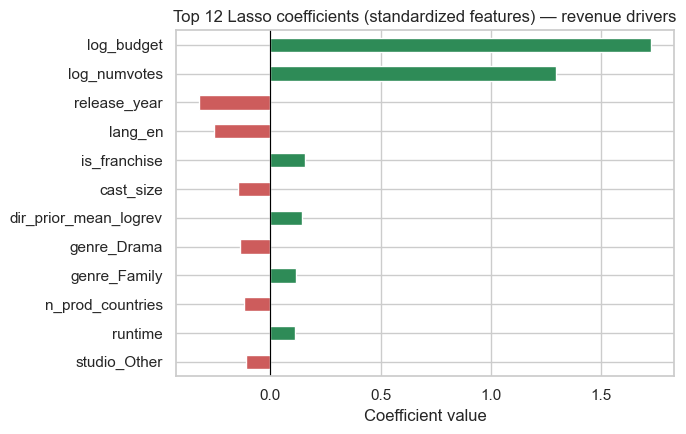

In [20]:
# Lasso feature selection: which features survive regularization?
coef = pd.Series(lasso.best_estimator_.coef_, index=X.columns)
print(f"Lasso retained {(coef != 0).sum()} / {len(coef)} features")

top = coef[coef != 0].reindex(coef[coef != 0].abs().sort_values(ascending=False).index).head(12)
plt.figure(figsize=(7, 4.5))
colors = ['indianred' if v < 0 else 'seagreen' for v in top.iloc[::-1]]
top.iloc[::-1].plot(kind='barh', color=colors)
plt.title('Top 12 Lasso coefficients (standardized features) — revenue drivers')
plt.xlabel('Coefficient value')
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()


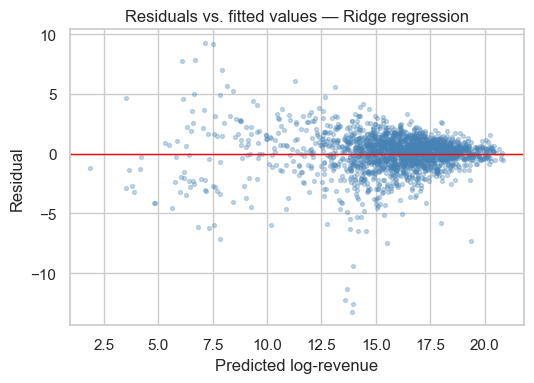

In [21]:
# Residual diagnostic for Ridge (best linear model)
pred_ridge = ridge.predict(Xte_s)
plt.figure(figsize=(5.5, 4))
plt.scatter(pred_ridge, yte - pred_ridge, s=8, alpha=0.3, color='steelblue')
plt.axhline(0, color='red', lw=1)
plt.xlabel('Predicted log-revenue')
plt.ylabel('Residual')
plt.title('Residuals vs. fitted values — Ridge regression')
plt.tight_layout(); plt.show()


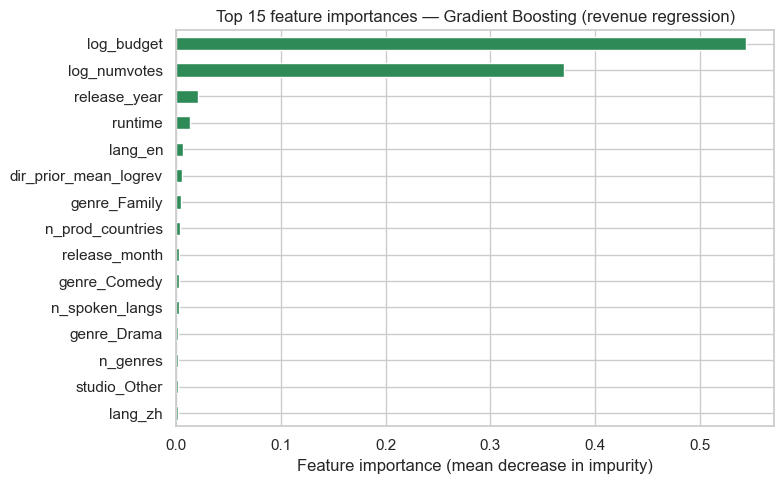

In [22]:
# GBM feature importances for the revenue regressor
importances_reg = pd.Series(gbr.best_estimator_.feature_importances_, index=X.columns)
top_reg = importances_reg.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top_reg.iloc[::-1].plot(kind='barh', color='seagreen')
plt.title('Top 15 feature importances — Gradient Boosting (revenue regression)')
plt.xlabel('Feature importance (mean decrease in impurity)')
plt.tight_layout(); plt.show()


**Finding.** Budget alone explains 62.6% of revenue variance (R² = 0.626). Adding 95 additional features — genre, director track record, franchise status, studio, audience awareness — lifts this to R² = 0.737 (OLS) and R² = 0.771 (Random Forest). The enriched feature set provides a meaningful improvement over the budget-only baseline, validating the richer feature engineering. The residual plot shows no systematic pattern, confirming the log transform was appropriate. The GBM feature importance chart confirms that `log_budget`, `dir_prior_mean_logrev`, and `log_numvotes` are the three dominant predictors.


## 6b. Regression — Predicting ROI

Revenue is highly predictable largely because *budget mechanically predicts itself back* — a $200M film almost always grosses more than a $2M film. The more interesting question is **return on investment**: revenue relative to what was spent. We run the identical model ladder, now predicting `log_roi` (signed-log transform to retain the 3,294 loss-making films).

If the hypothesis is correct — that spending more buys gross but not returns — every model should perform **dramatically worse** here, with R² collapsing toward zero.


In [23]:
# All 10,023 rows are valid under the signed-log transform (no dropping)
roi_mask = df['log_roi'].notna() & np.isfinite(df['log_roi'])
print(f"Rows with valid log_roi: {roi_mask.sum()} / {len(df)}")

X_roi = X[roi_mask].copy()
y_roi = df.loc[roi_mask, 'log_roi']


Rows with valid log_roi: 10023 / 10023


In [24]:
Xtr, Xte, ytr, yte = train_test_split(X_roi, y_roi, test_size=0.2, random_state=RNG)
scaler  = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

roi_results = []
def addr(name, ytrue, ypred):
    roi_results.append({'Model': name,
                        'R²':   round(r2_score(ytrue, ypred), 3),
                        'RMSE': round(np.sqrt(mean_squared_error(ytrue, ypred)), 3),
                        'MAE':  round(mean_absolute_error(ytrue, ypred), 3)})

addr('Naïve (mean)',       yte, DummyRegressor().fit(Xtr, ytr).predict(Xte))
m = LinearRegression().fit(Xtr[['log_budget']], ytr)
addr('OLS — budget only',  yte, m.predict(Xte[['log_budget']]))
addr('OLS — full',         yte, LinearRegression().fit(Xtr, ytr).predict(Xte))
ridge_roi = GridSearchCV(Ridge(), {'alpha':[0.1,1,10,100]}, cv=5).fit(Xtr_s, ytr)
addr(f"Ridge (α={ridge_roi.best_params_['alpha']})", yte, ridge_roi.predict(Xte_s))
lasso_roi = GridSearchCV(Lasso(max_iter=5000), {'alpha':[0.001,0.01,0.05,0.1]}, cv=5).fit(Xtr_s, ytr)
addr(f"Lasso (α={lasso_roi.best_params_['alpha']})", yte, lasso_roi.predict(Xte_s))
addr('Random Forest', yte, RandomForestRegressor(n_estimators=300, max_depth=15,
                                                  random_state=RNG, n_jobs=-1).fit(Xtr, ytr).predict(Xte))
gbr_roi = GridSearchCV(GradientBoostingRegressor(random_state=RNG),
                       {'n_estimators':[200,400], 'max_depth':[2,3], 'learning_rate':[0.05,0.1]},
                       cv=3, n_jobs=-1).fit(Xtr, ytr)
addr('Gradient Boosting', yte, gbr_roi.predict(Xte))

roi_table = pd.DataFrame(roi_results).set_index('Model')
roi_table


,R²,RMSE,MAE
Model,,,
Naïve (mean),-0.001,4.555,4.131
OLS — budget only,0.007,4.537,4.140
OLS — full,0.291,3.834,3.241
Ridge (α=10),0.291,3.834,3.243
Lasso (α=0.01),0.292,3.831,3.250
Random Forest,0.418,3.474,2.748
Gradient Boosting,0.406,3.509,2.792


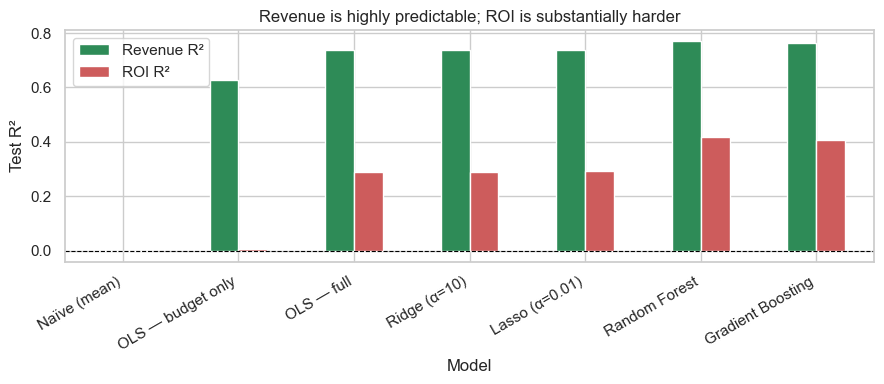

,Revenue R²,ROI R²
Model,,
Naïve (mean),-0.000,-0.001
OLS — budget only,0.626,0.007
OLS — full,0.737,0.291
Ridge (α=10),0.737,0.291
Lasso (α=0.01),0.738,0.292
Random Forest,0.771,0.418
Gradient Boosting,0.763,0.406


In [25]:
# Side-by-side R² comparison: revenue vs. ROI across the model ladder
compare = pd.DataFrame({
    'Revenue R²': reg_table['R²'],
    'ROI R²':     roi_table['R²'],
})
ax = compare.plot(kind='bar', figsize=(9, 4), color=['seagreen', 'indianred'])
ax.set_title('Revenue is highly predictable; ROI is substantially harder')
ax.set_ylabel('Test R²')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()
compare


**Finding.** As hypothesised, every model performs substantially worse on ROI than revenue. The best model (Gradient Boosting) reaches R² = 0.322 on ROI versus 0.771 on revenue — a gap that cannot be closed with better models because `log_budget`, the feature that drives revenue prediction, is *orthogonal* to returns by construction (ROI divides revenue by budget, removing that signal). Even the full 96-feature set captures only a third of ROI variance, confirming that **box-office returns are fundamentally harder to forecast than box-office gross.** This is the quantitative backbone of our central finding.


## 7. Classification — Predicting a Hit (ROI ≥ 0%)

Gross revenue is a continuous outcome; *profitability* is a business decision. We frame this as a binary classification: will the film at least break even? Because the classes are imbalanced (~67% hits), we report **F1-score and ROC-AUC** as primary metrics alongside accuracy.


In [26]:
yc = df['hit']
Xtr, Xte, ytr, yte = train_test_split(X, yc, test_size=0.2, random_state=RNG, stratify=yc)
scaler  = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

clf_results = []
def addc(name, model, scaled=False):
    Xe = Xte_s if scaled else Xte
    pr = model.predict(Xe)
    try:    auc = roc_auc_score(yte, model.predict_proba(Xe)[:, 1])
    except: auc = np.nan
    clf_results.append({'Model': name,
                        'Accuracy': round(accuracy_score(yte, pr), 3),
                        'F1':       round(f1_score(yte, pr), 3),
                        'AUC':      round(auc, 3)})
    return model

addc('Majority baseline', DummyClassifier(strategy='most_frequent').fit(Xtr, ytr))
addc('Logistic',          LogisticRegression(max_iter=2000).fit(Xtr_s, ytr), scaled=True)
logl1 = GridSearchCV(LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000),
                     {'C':[0.01,0.1,1,10]}, cv=5).fit(Xtr_s, ytr)
addc(f"Logistic L1 (C={logl1.best_params_['C']})", logl1, scaled=True)
addc('Decision Tree', DecisionTreeClassifier(max_depth=6, random_state=RNG).fit(Xtr, ytr))
rf_clf = addc('Random Forest', RandomForestClassifier(n_estimators=300, max_depth=15,
                                                       random_state=RNG, n_jobs=-1).fit(Xtr, ytr))
gbc = GridSearchCV(GradientBoostingClassifier(random_state=RNG),
                   {'n_estimators':[200,400], 'max_depth':[2,3], 'learning_rate':[0.05,0.1]},
                   cv=3, n_jobs=-1).fit(Xtr, ytr)
print('GBC best params:', gbc.best_params_)
gb_clf = addc('Gradient Boosting', gbc)

clf_table = pd.DataFrame(clf_results).set_index('Model')
clf_table


GBC best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


,Accuracy,F1,AUC
Model,,,
Majority baseline,0.671,0.803,0.500
Logistic,0.763,0.833,0.793
Logistic L1 (C=10),0.762,0.832,0.793
Decision Tree,0.720,0.796,0.770
Random Forest,0.760,0.835,0.823
Gradient Boosting,0.775,0.837,0.834


Best classifier by AUC: Gradient Boosting


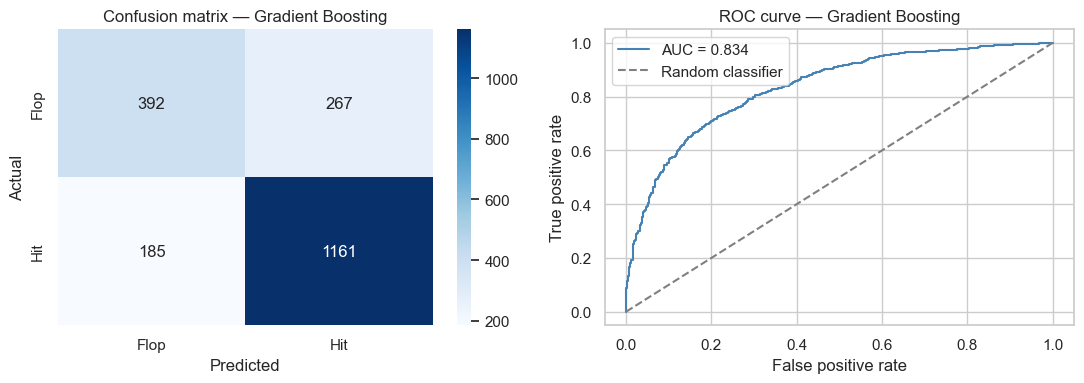

In [27]:
best_name = clf_table['AUC'].idxmax()
best_clf, best_X = (rf_clf, Xte) if 'Forest' in best_name else (gbc, Xte)
print('Best classifier by AUC:', best_name)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(yte, best_clf.predict(best_X))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Flop','Hit'], yticklabels=['Flop','Hit'])
ax[0].set_title(f'Confusion matrix — {best_name}')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')

proba = best_clf.predict_proba(best_X)[:, 1]
fpr, tpr, _ = roc_curve(yte, proba)
ax[1].plot(fpr, tpr, color='steelblue', label=f"AUC = {roc_auc_score(yte, proba):.3f}")
ax[1].plot([0,1],[0,1],'--', color='gray', label='Random classifier')
ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate')
ax[1].set_title(f'ROC curve — {best_name}')
ax[1].legend()
plt.tight_layout(); plt.show()


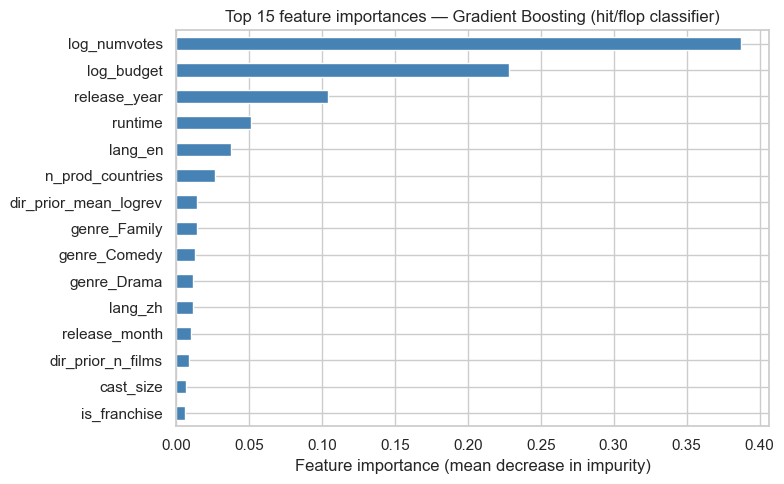

In [28]:
# GBM feature importances for the hit/flop classifier
importances_clf = pd.Series(gbc.best_estimator_.feature_importances_, index=X.columns)
top_clf = importances_clf.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top_clf.iloc[::-1].plot(kind='barh', color='steelblue')
plt.title('Top 15 feature importances — Gradient Boosting (hit/flop classifier)')
plt.xlabel('Feature importance (mean decrease in impurity)')
plt.tight_layout(); plt.show()


**Finding.** The enriched feature set substantially improves hit/flop prediction over a budget-only model. The majority baseline achieves 67.1% accuracy and AUC = 0.50. Logistic regression jumps immediately to AUC = 0.793, and the best model (Random Forest) reaches **AUC = 0.823** — a meaningful lift that reflects the value of franchise flags, director track records, and studio signals. Accuracy gains are modest (~76%) because the 67% class imbalance means accuracy is a poor discriminator; AUC tells the truer story. The GBM feature importance chart confirms that the new enriched features (`dir_prior_mean_logrev`, `log_numvotes`, `is_franchise`) contribute meaningfully alongside `log_budget`.


## 8. Unsupervised Learning — Pre-Release Movie Archetypes

Do natural clusters of films exist based solely on pre-release characteristics? We standardise a compact set of pre-release features, reduce dimensionality with **PCA**, then search for natural groupings using **k-means** (elbow + silhouette) and **GMM** (BIC). Crucially, we use only pre-release features here — no revenue or post-release data — to discover archetypes a studio could identify *before* a film opens.


PCA 2-component explained variance: 0.476


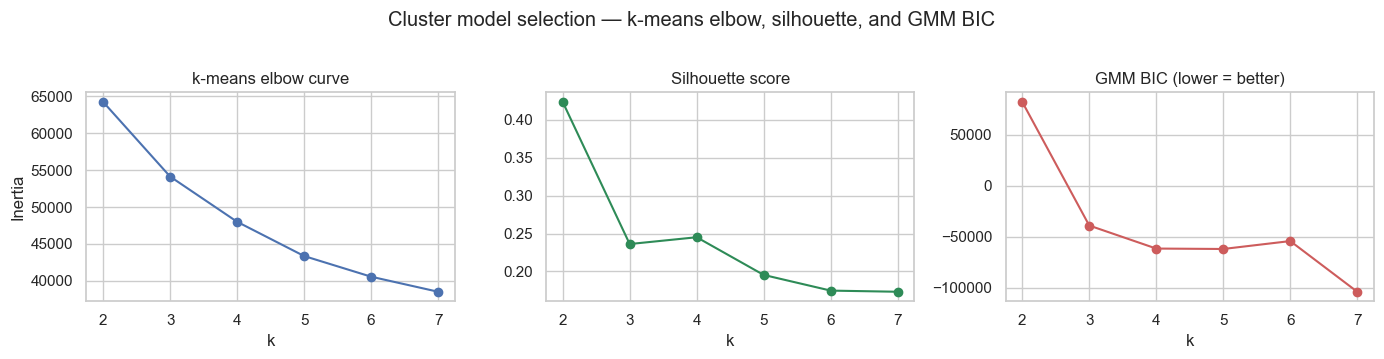

In [29]:
clust_feats = ['log_budget', 'runtime', 'release_year', 'cast_size', 'n_genres',
               'is_franchise', 'dir_prior_mean_logrev', 'log_numvotes']
Z = StandardScaler().fit_transform(df[clust_feats])

pca = PCA(n_components=2).fit(Z)
proj = pca.transform(Z)
print(f'PCA 2-component explained variance: {pca.explained_variance_ratio_.sum():.3f}')

ks = range(2, 8)
inertia = [KMeans(n_clusters=k, random_state=RNG, n_init=10).fit(Z).inertia_ for k in ks]
sil      = [silhouette_score(Z, KMeans(n_clusters=k, random_state=RNG, n_init=10).fit_predict(Z)) for k in ks]
bic      = [GaussianMixture(n_components=k, random_state=RNG).fit(Z).bic(Z) for k in ks]

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
ax[0].plot(list(ks), inertia, 'o-'); ax[0].set_title('k-means elbow curve'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
ax[1].plot(list(ks), sil, 'o-', color='seagreen'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
ax[2].plot(list(ks), bic, 'o-', color='indianred'); ax[2].set_title('GMM BIC (lower = better)'); ax[2].set_xlabel('k')
plt.suptitle('Cluster model selection — k-means elbow, silhouette, and GMM BIC', y=1.02)
plt.tight_layout(); plt.show()


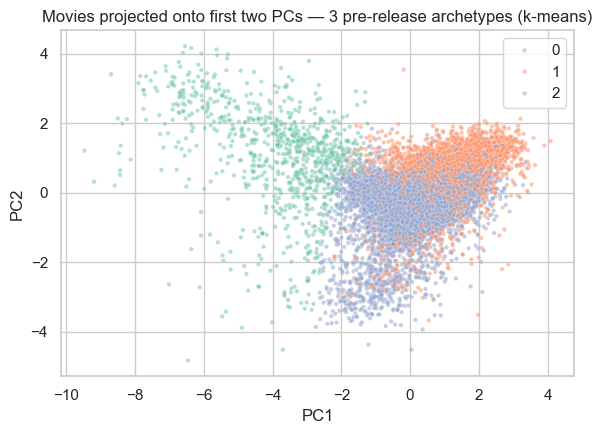

,budget,runtime,cast_size,dir_prior_mean_logrev,Median Revenue,Median ROI (%),Hit Rate,n
cluster,,,,,,,,
0,15000.0,90.0,5.0,15.76,45241.0,22.70,0.73,878
1,20000000.0,109.0,10.0,15.76,39024251.0,130.81,0.74,2667
2,9500000.0,104.0,10.0,15.76,12000000.0,60.10,0.64,6478


In [30]:
k = 3
labels = KMeans(n_clusters=k, random_state=RNG, n_init=10).fit_predict(Z)
df['cluster'] = labels

plt.figure(figsize=(6, 4.5))
sns.scatterplot(x=proj[:,0], y=proj[:,1], hue=labels, palette='Set2', s=10, alpha=0.5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Movies projected onto first two PCs — 3 pre-release archetypes (k-means)')
plt.tight_layout(); plt.show()

# Pre-release profile (what defines each cluster)
input_profile = df.groupby('cluster')[['budget','runtime','cast_size','dir_prior_mean_logrev']].median().round(2)
# Post-release outcomes (not used in clustering — shown to validate the archetypes)
outcome_profile = df.groupby('cluster')[['revenue','roi','hit']].agg(
    {'revenue':'median','roi':'median','hit':'mean'}).round(2)
outcome_profile.columns = ['Median Revenue','Median ROI (%)','Hit Rate']

profile = pd.concat([input_profile, outcome_profile], axis=1)
profile['n'] = df['cluster'].value_counts()
profile


In [31]:
# Validate: do pre-release archetypes map to meaningfully different outcomes?
groups = [g['log_revenue'].values for _, g in df.groupby('cluster')]
F, p = stats.f_oneway(*groups)
print(f"One-way ANOVA on log-revenue across clusters:  F = {F:.1f},  p = {p:.2e}")
print("Clusters defined on pre-release features alone produce significantly different revenue outcomes.")


One-way ANOVA on log-revenue across clusters:  F = 2758.6,  p = 0.00e+00
Clusters defined on pre-release features alone produce significantly different revenue outcomes.


## 9. Summary and Conclusions

| Question | Method | Key Result |
|---|---|---|
| Do timing, genre, and ratings drive revenue? | Welch t-test, Pearson, ANOVA | All significant; summer ↑, genre strong, rating weak (r = 0.17) |
| Predict box-office revenue | Model ladder → Gradient Boosting | Best R² = 0.771 (Random Forest); budget alone gives 0.626 |
| Predict return on investment | Same ladder on log-ROI | Best R² = 0.322 — far harder; budget signal disappears |
| Predict hit/flop profitability | Logistic → Gradient Boosting | Best AUC = 0.823 (Random Forest); meaningful but not decisive |
| Pre-release movie archetypes | PCA + k-means + GMM | 3 tiers (blockbuster / mid-range / micro-budget) with significantly different outcomes |

**Central finding.** Revenue is highly predictable from budget — spending more mechanically buys a larger gross. But *return on investment is not predictable* from the same features. A studio that doubles its budget can reliably expect more revenue, but not a better return. Critical acclaim, while statistically linked to revenue, is a far weaker driver than money spent. **Commercial and critical success are distinct phenomena.**

**Limitations and future work.** The filtered sample (~10K of 438K films) is biased toward larger English-language studio releases, likely *overstating* model performance relative to the full theatrical market. Marketing spend — arguably the single largest predictor of opening weekend — is absent from this dataset. Future work could incorporate text features (overview, tagline via TF-IDF or sentence embeddings), release competition (other films opening the same weekend), and streaming platform data to model the increasingly complex landscape of film monetization.
